# Notebook 02 — Análise de Robustez

Esse notebook é a continuação do notebook 01 (treinamento e avaliação dos modelos). Aqui o objetivo é testar o quão confiáveis são os resultados que obtivemos, usando validação cruzada, curvas de aprendizado e uma análise dos erros do melhor modelo (Naive Bayes).

O que tem aqui:
- Validação cruzada com k=5 e k=10 pra Naive Bayes e Regressão Logística
- Curvas de aprendizado pra ver se os modelos se beneficiam de mais dados
- Análise de erros: quais frases o modelo erra, de qual fonte (ChatGPT/Claude/Gemini) e por quê

In [1]:
# ============================================================
# CÉLULA DE SETUP — padrão + carregamento do dataset sintético
# ============================================================
import os, sys, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)
from sklearn.pipeline import Pipeline

sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

# Detecção de ambiente
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    if not os.path.exists('/content/tcc-analise-sentimento'):
        os.system('git clone https://github.com/ROMAUSKI/tcc-analise-sentimento.git /content/tcc-analise-sentimento')
    else:
        os.system('cd /content/tcc-analise-sentimento && git pull')
    BASE_DIR = '/content/tcc-analise-sentimento'
else:
    BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Caminhos do projeto
DADOS_BRUTOS_MOVIES = os.path.join(BASE_DIR, 'dados', 'brutos')
DADOS_BRUTOS_APPS   = os.path.join(BASE_DIR, 'dados', 'brutos_apps')
DADOS_PROCESSADO    = os.path.join(BASE_DIR, 'dados', 'processado')
RESULTADOS          = os.path.join(BASE_DIR, 'resultados')
os.makedirs(RESULTADOS, exist_ok=True)

# Alias para compatibilidade com células existentes do notebook 02
dir_resultados = RESULTADOS

# Carrega o dataset sintético processado (gerado pelo notebook 01)
caminho_csv = os.path.join(DADOS_PROCESSADO, 'synthetic_dataset.csv')
df = pd.read_csv(caminho_csv)
df = df.dropna(subset=['frase_limpa'])
X = df['frase_limpa']
y = df['classe']

print(f'Ambiente: {"Colab" if IN_COLAB else "Local"}')
print(f'BASE_DIR: {BASE_DIR}')
print(f'Dataset carregado: {len(df)} amostras')
print(y.value_counts())


Dataset carregado: 1800 amostras
classe
Positiva    600
Neutra      600
Negativa    600
Name: count, dtype: int64


In [2]:
# validacao cruzada com accuracy e f1
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

def criar_pipeline(clf):
    return Pipeline([('tfidf', TfidfVectorizer(max_features=5000)), ('clf', clf)])

experimentos = [
    ('Naive Bayes (k=5)',  MultinomialNB(), 5),
    ('Naive Bayes (k=10)', MultinomialNB(), 10),
    ('Reg. Logística (k=5)',  LogisticRegression(max_iter=1000), 5),
    ('Reg. Logística (k=10)', LogisticRegression(max_iter=1000), 10),
    ('SVM Linear (k=5)',  LinearSVC(max_iter=5000), 5),
    ('SVM Linear (k=10)', LinearSVC(max_iter=5000), 10),
]

resultados = []
for nome, clf, k in experimentos:
    acc = cross_val_score(criar_pipeline(clf), X, y, cv=k, scoring='accuracy')
    f1  = cross_val_score(criar_pipeline(clf), X, y, cv=k, scoring='f1_weighted')
    resultados.append({'Modelo': nome, 'k': k,
                       'Acc Média': acc.mean(), 'Acc DP': acc.std(),
                       'F1 Média': f1.mean(), 'F1 DP': f1.std(),
                       'Scores Acc': acc, 'Scores F1': f1})
    print(f'{nome}: Acc={acc.mean()*100:.2f}% (±{acc.std()*100:.2f}) | F1={f1.mean()*100:.2f}% (±{f1.std()*100:.2f})')

# montar tabela
linhas = []
for r in resultados:
    linhas.append({
        'Modelo': r['Modelo'], 'k': r['k'],
        'Accuracy (%)': f"{r['Acc Média']*100:.2f} ± {r['Acc DP']*100:.2f}",
        'F1-Score (%)': f"{r['F1 Média']*100:.2f} ± {r['F1 DP']*100:.2f}"
    })
df_cv = pd.DataFrame(linhas)
df_cv

Naive Bayes (k=5): Acc=88.72% (±1.83) | F1=88.76% (±1.83)
Naive Bayes (k=10): Acc=89.50% (±2.16) | F1=89.53% (±2.15)
Reg. Logística (k=5): Acc=87.17% (±1.46) | F1=87.16% (±1.46)
Reg. Logística (k=10): Acc=87.94% (±2.30) | F1=87.92% (±2.32)
SVM Linear (k=5): Acc=89.00% (±1.33) | F1=89.00% (±1.33)
SVM Linear (k=10): Acc=89.17% (±2.46) | F1=89.16% (±2.47)


,Modelo,k,Accuracy (%),F1-Score (%)
0,Naive Bayes (k=5),5,88.72 ± 1.83,88.76 ± 1.83
1,Naive Bayes (k=10),10,89.50 ± 2.16,89.53 ± 2.15
2,Reg. Logística (k=5),5,87.17 ± 1.46,87.16 ± 1.46
3,Reg. Logística (k=10),10,87.94 ± 2.30,87.92 ± 2.32
4,SVM Linear (k=5),5,89.00 ± 1.33,89.00 ± 1.33
5,SVM Linear (k=10),10,89.17 ± 2.46,89.16 ± 2.47


In [3]:
df_cv.to_csv(os.path.join(dir_resultados, 'validacao_cruzada.csv'), index=False)
print('salvo em resultados/validacao_cruzada.csv')

salvo em resultados/validacao_cruzada.csv


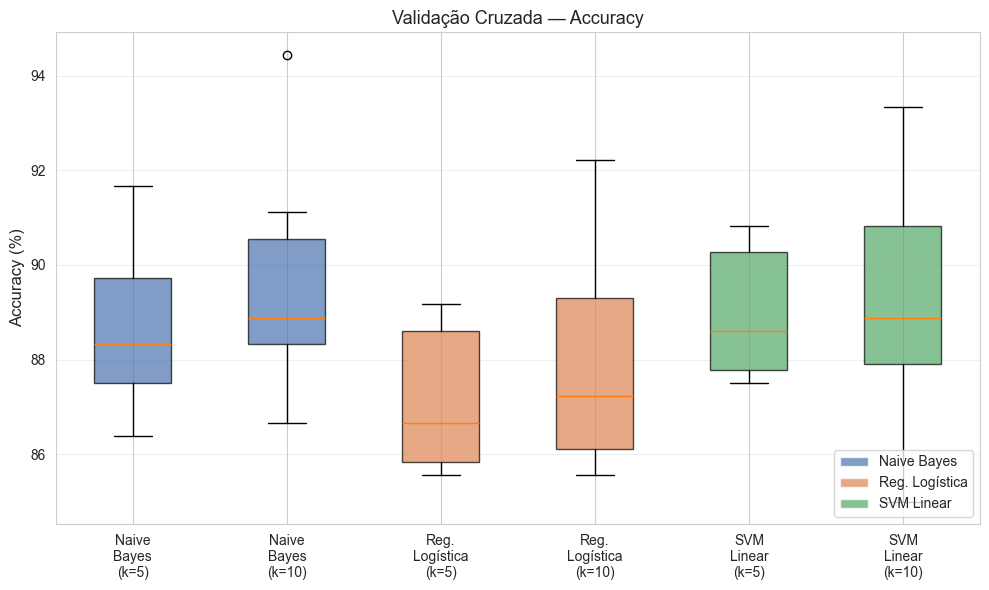

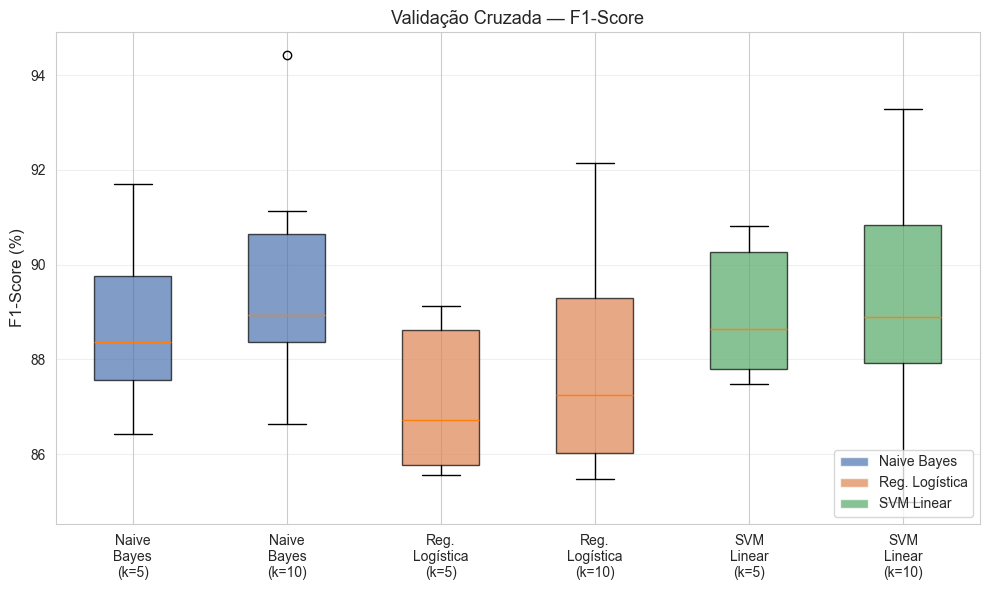

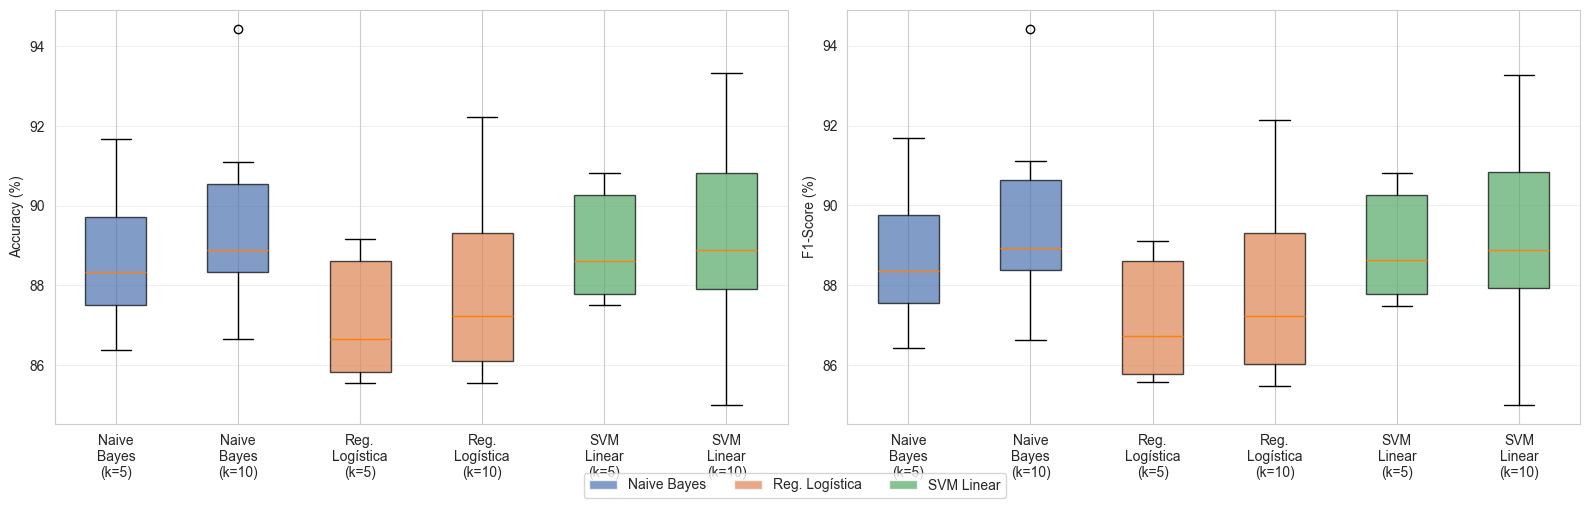

Salvos: boxplot_accuracy.png, boxplot_f1.png, boxplot_validacao_cruzada.png


In [4]:
# =============================================
# BOXPLOTS SEPARADOS — Accuracy e F1-Score
# =============================================
cores = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452', '#55A868', '#55A868']
from matplotlib.patches import Patch
legenda = [Patch(facecolor='#4C72B0', alpha=0.7, label='Naive Bayes'),
           Patch(facecolor='#DD8452', alpha=0.7, label='Reg. Logística'),
           Patch(facecolor='#55A868', alpha=0.7, label='SVM Linear')]

# --- Boxplot Accuracy ---
fig, ax = plt.subplots(figsize=(10, 6))
dados_acc = {r['Modelo']: r['Scores Acc'] * 100 for r in resultados}
bp = ax.boxplot(dados_acc.values(),
                labels=[n.replace(' ', '\n') for n in dados_acc.keys()],
                patch_artist=True, widths=0.5)
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Validação Cruzada — Accuracy', fontsize=13)
ax.grid(axis='y', alpha=0.3)
ax.legend(handles=legenda, loc='lower right')
plt.tight_layout()
fig.savefig(os.path.join(dir_resultados, 'boxplot_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Boxplot F1-Score ---
fig, ax = plt.subplots(figsize=(10, 6))
dados_f1 = {r['Modelo']: r['Scores F1'] * 100 for r in resultados}
bp = ax.boxplot(dados_f1.values(),
                labels=[n.replace(' ', '\n') for n in dados_f1.keys()],
                patch_artist=True, widths=0.5)
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
ax.set_ylabel('F1-Score (%)', fontsize=12)
ax.set_title('Validação Cruzada — F1-Score', fontsize=13)
ax.grid(axis='y', alpha=0.3)
ax.legend(handles=legenda, loc='lower right')
plt.tight_layout()
fig.savefig(os.path.join(dir_resultados, 'boxplot_f1.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Combinado (referência) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
bp1 = ax1.boxplot(dados_acc.values(),
                  labels=[n.replace(' ', '\n') for n in dados_acc.keys()],
                  patch_artist=True, widths=0.5)
for patch, cor in zip(bp1['boxes'], cores):
    patch.set_facecolor(cor); patch.set_alpha(0.7)
ax1.set_ylabel('Accuracy (%)')
ax1.grid(axis='y', alpha=0.3)

bp2 = ax2.boxplot(dados_f1.values(),
                  labels=[n.replace(' ', '\n') for n in dados_f1.keys()],
                  patch_artist=True, widths=0.5)
for patch, cor in zip(bp2['boxes'], cores):
    patch.set_facecolor(cor); patch.set_alpha(0.7)
ax2.set_ylabel('F1-Score (%)')
ax2.grid(axis='y', alpha=0.3)

fig.legend(handles=legenda, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
fig.savefig(os.path.join(dir_resultados, 'boxplot_validacao_cruzada.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Salvos: boxplot_accuracy.png, boxplot_f1.png, boxplot_validacao_cruzada.png')

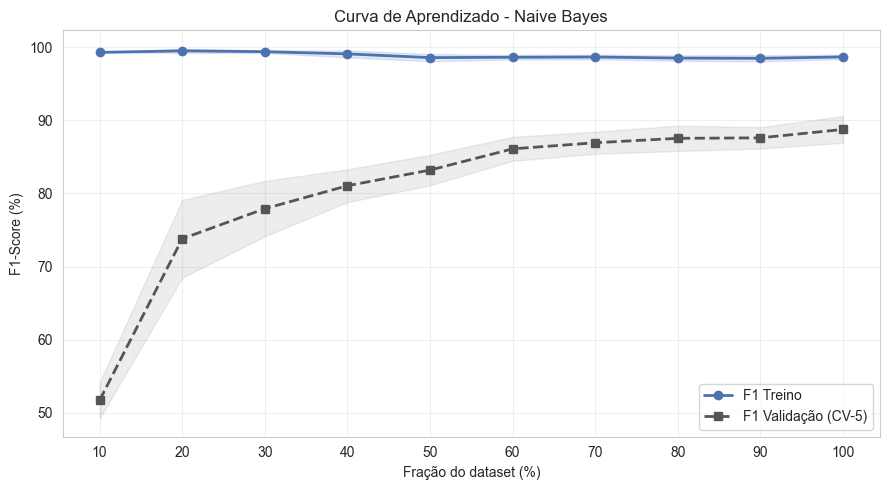

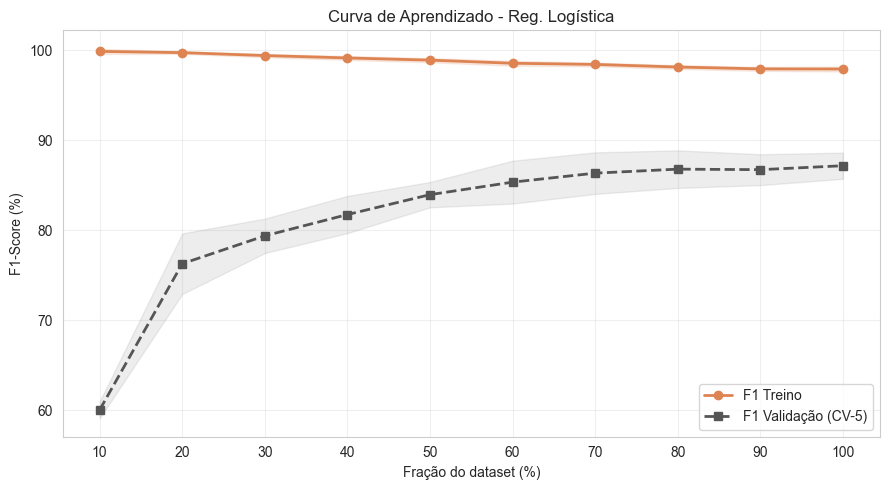

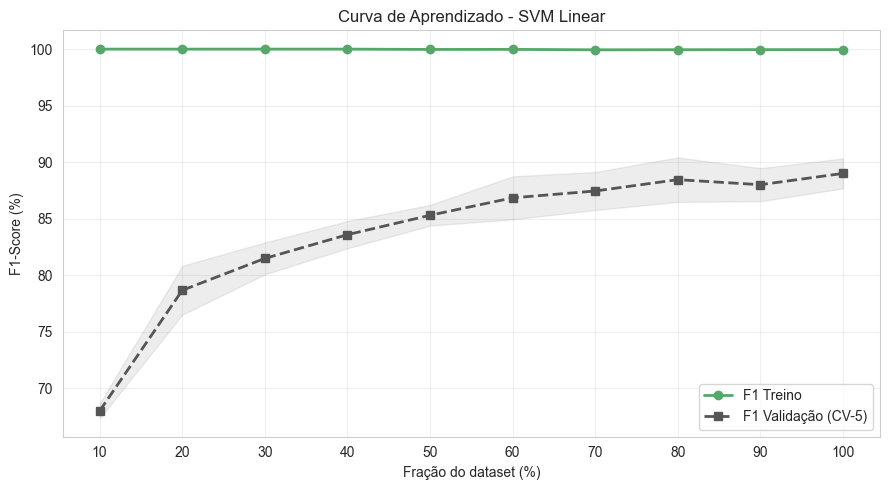

In [5]:
# curvas de aprendizado
from sklearn.svm import LinearSVC
fracs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

modelos_lc = [
    ('Naive Bayes', MultinomialNB(), '#4C72B0', 'curva_aprendizado_nb.png'),
    ('Reg. Logística', LogisticRegression(max_iter=1000), '#DD8452', 'curva_aprendizado_lr.png'),
    ('SVM Linear', LinearSVC(max_iter=5000), '#55A868', 'curva_aprendizado_svm.png'),
]

for nome, clf, cor, arquivo in modelos_lc:
    pipe = Pipeline([('tfidf', TfidfVectorizer(max_features=5000)), ('clf', clf)])
    sizes, tr_scores, val_scores = learning_curve(
        pipe, X, y, train_sizes=fracs, cv=5, scoring='f1_weighted', n_jobs=-1, random_state=42)

    tr_mean = tr_scores.mean(axis=1) * 100
    val_mean = val_scores.mean(axis=1) * 100
    tr_std = tr_scores.std(axis=1) * 100
    val_std = val_scores.std(axis=1) * 100
    pct = [f * 100 for f in fracs]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(pct, tr_mean, 'o-', color=cor, label='F1 Treino', linewidth=2)
    ax.fill_between(pct, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color=cor)
    ax.plot(pct, val_mean, 's--', color='#555', label='F1 Validação (CV-5)', linewidth=2)
    ax.fill_between(pct, val_mean - val_std, val_mean + val_std, alpha=0.10, color='#555')
    ax.set_title(f'Curva de Aprendizado - {nome}')
    ax.set_xlabel('Fração do dataset (%)')
    ax.set_ylabel('F1-Score (%)')
    ax.set_xticks(pct)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(dir_resultados, arquivo), dpi=150, bbox_inches='tight')
    plt.show()

## Curvas de aprendizado

O Naive Bayes converge rápido, a partir de uns 50-60% do dataset a curva de validação já estabiliza e o overfitting é praticamente zero. Ou seja, adicionar mais dados sintéticos parecidos provavelmente não vai melhorar muito.

A Regressão Logística demora mais pra convergir (lá pelos 70-80%) e tem uma diferença maior entre treino e validação, mas essa diferença vai diminuindo conforme o dataset cresce. Provavelmente se beneficiaria de mais dados.

O SVM Linear tem comportamento parecido com a Regressão Logística em termos de convergência, mas tende a ter um gap um pouco maior entre treino e validação. Isso faz sentido porque o SVM busca a margem máxima, o que pode levar a um ajuste mais forte nos dados de treino.

No geral o NB é mais estável entre folds e converge mais rápido, o que faz sentido pro tamanho do dataset que temos. LR e SVM oscilam mais mas tendem a se aproximar do NB com mais dados.

In [6]:
# treinar NB e identificar erros no teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

tfidf = TfidfVectorizer()
nb_model = MultinomialNB()
nb_model.fit(tfidf.fit_transform(X_train), y_train)
y_pred = nb_model.predict(tfidf.transform(X_test))

print(classification_report(y_test, y_pred))

df_test = df.loc[X_test.index].copy()
df_test['predita'] = y_pred
df_test['acertou'] = df_test['classe'] == df_test['predita']
erros = df_test[~df_test['acertou']]
print(f'\nErros: {len(erros)}/{len(df_test)} ({len(erros)/len(df_test)*100:.1f}%)')

              precision    recall  f1-score   support

    Negativa       0.86      0.90      0.88       120
      Neutra       0.91      0.87      0.89       120
    Positiva       0.86      0.87      0.86       120

    accuracy                           0.88       360
   macro avg       0.88      0.88      0.88       360
weighted avg       0.88      0.88      0.88       360


Erros: 44/360 (12.2%)


In [7]:
# erros por fonte
print('Erros por IA geradora:')
for fonte in sorted(df_test['fonte'].unique()):
    total = len(df_test[df_test['fonte'] == fonte])
    n_erros = len(erros[erros['fonte'] == fonte])
    print(f'  {fonte}: {n_erros}/{total} ({n_erros/total*100:.1f}%)')

# confusoes mais comuns
print('\nConfusões mais comuns:')
confusoes = erros.groupby(['classe', 'predita']).size().sort_values(ascending=False)
for (real, pred), n in confusoes.items():
    print(f'  {real} -> {pred}: {n}')

Erros por IA geradora:
  ChatGPT: 9/106 (8.5%)
  Claude: 15/127 (11.8%)
  Gemini: 20/127 (15.7%)

Confusões mais comuns:
  Positiva -> Negativa: 10
  Neutra -> Positiva: 9
  Negativa -> Positiva: 8
  Neutra -> Negativa: 7
  Positiva -> Neutra: 6
  Negativa -> Neutra: 4


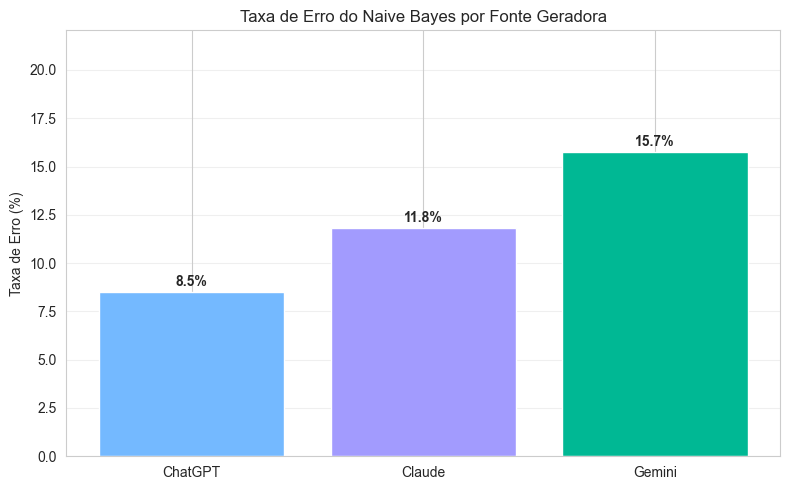

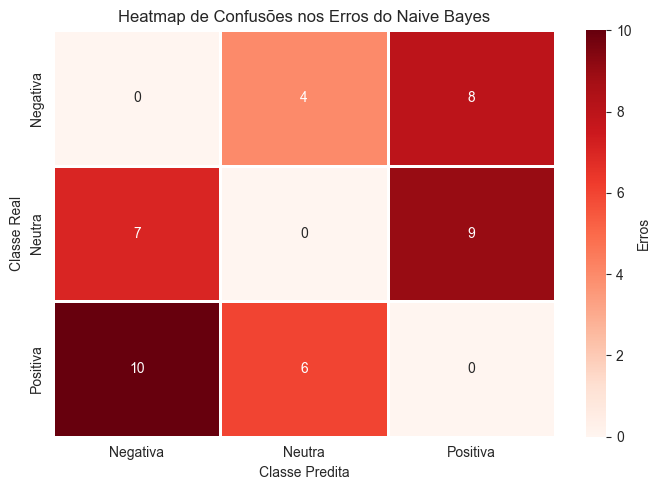

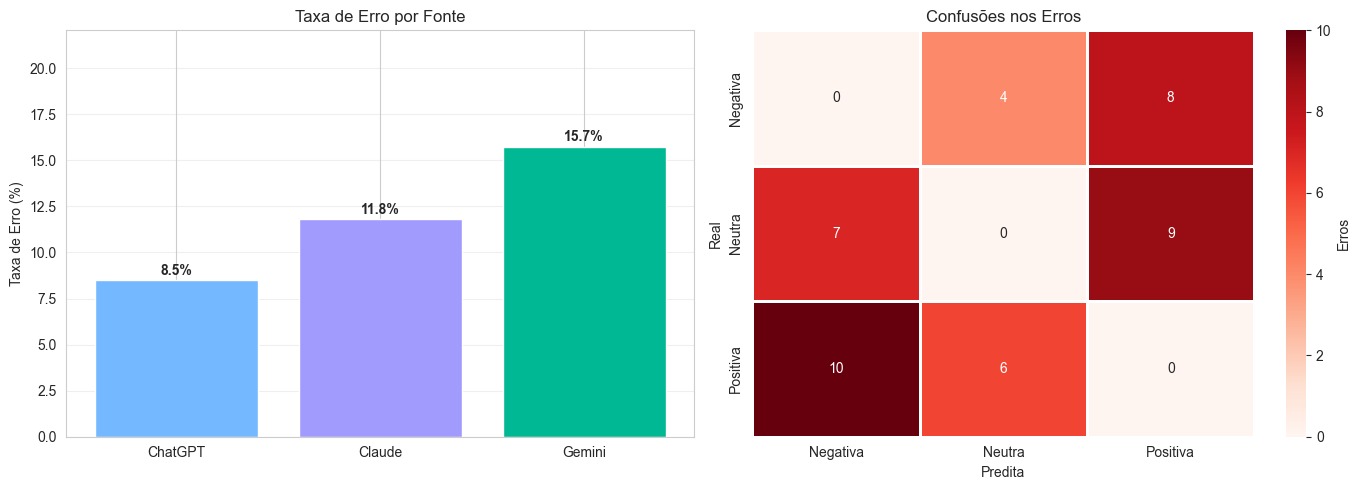

Salvos: erros_por_fonte.png, erros_heatmap.png, analise_erros_graficos.png


In [8]:
from sklearn.metrics import confusion_matrix

# =============================================
# GRÁFICOS DE ERROS — Separados + Combinado
# =============================================
fontes = sorted(df_test['fonte'].unique())
cores_fonte = {'ChatGPT': '#74b9ff', 'Claude': '#a29bfe', 'Gemini': '#00b894'}
taxas = []
for f in fontes:
    total = len(df_test[df_test['fonte'] == f])
    n_err = len(erros[erros['fonte'] == f])
    taxas.append(n_err / total * 100)

classes = ['Negativa', 'Neutra', 'Positiva']
cm = confusion_matrix(erros['classe'], erros['predita'], labels=classes)

# --- Erro por fonte (separado) ---
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(fontes, taxas, color=[cores_fonte[f] for f in fontes])
for bar, taxa in zip(bars, taxas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{taxa:.1f}%', ha='center', fontweight='bold')
ax.set_title('Taxa de Erro do Naive Bayes por Fonte Geradora')
ax.set_ylabel('Taxa de Erro (%)')
ax.set_ylim(0, max(taxas) * 1.4)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(dir_resultados, 'erros_por_fonte.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Heatmap erros (separado) ---
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=classes, yticklabels=classes,
            linewidths=1, cbar_kws={'label': 'Erros'})
ax.set_title('Heatmap de Confusões nos Erros do Naive Bayes')
ax.set_xlabel('Classe Predita')
ax.set_ylabel('Classe Real')
plt.tight_layout()
fig.savefig(os.path.join(dir_resultados, 'erros_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Combinado (referência) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
bars = ax1.bar(fontes, taxas, color=[cores_fonte[f] for f in fontes])
for bar, taxa in zip(bars, taxas):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{taxa:.1f}%', ha='center', fontweight='bold')
ax1.set_title('Taxa de Erro por Fonte')
ax1.set_ylabel('Taxa de Erro (%)')
ax1.set_ylim(0, max(taxas) * 1.4)
ax1.grid(axis='y', alpha=0.3)

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax2,
            xticklabels=classes, yticklabels=classes,
            linewidths=1, cbar_kws={'label': 'Erros'})
ax2.set_title('Confusões nos Erros')
ax2.set_xlabel('Predita')
ax2.set_ylabel('Real')

plt.tight_layout()
fig.savefig(os.path.join(dir_resultados, 'analise_erros_graficos.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Salvos: erros_por_fonte.png, erros_heatmap.png, analise_erros_graficos.png')

In [9]:
# alguns exemplos de erros (variando tipo de confusao e fonte)
exemplos = []
for (real, pred), grupo in erros.groupby(['classe', 'predita']):
    for fonte in grupo['fonte'].unique():
        if len(exemplos) < 15:
            exemplos.append(grupo[grupo['fonte'] == fonte].iloc[0])

for i, row in enumerate(exemplos):
    print(f"[{i+1:02d}] {row['fonte']} | {row['classe']} -> {row['predita']}")
    print(f'     "{row["frase"]}"')
    print()

# salvar em csv
df_ex = pd.DataFrame(exemplos)[['frase', 'classe', 'predita', 'fonte']]
df_ex.to_csv(os.path.join(dir_resultados, 'analise_erros.csv'), index=False, encoding='utf-8-sig')
print(f'Salvo: resultados/analise_erros.csv ({len(df_ex)} exemplos)')

[01] Claude | Negativa -> Neutra
     "A cinematografia abusa de câmera tremida ao ponto de causar enjoo físico nos espectadores."

[02] Gemini | Negativa -> Neutra
     "A premissa foi abandonada no meio do caminho por uma história diferente."

[03] ChatGPT | Negativa -> Positiva
     "O roteiro tem buracos enormes e inexplicáveis."

[04] Claude | Negativa -> Positiva
     "O filme não respeita a inteligência emocional do público ao telegrafar todos os momentos emocionais."

[05] Gemini | Negativa -> Positiva
     "A atuação inexpressiva do ator principal arruinou o filme."

[06] ChatGPT | Neutra -> Negativa
     "O som não diegético é adicionado apenas para o público."

[07] Gemini | Neutra -> Negativa
     "O roteiro de 'Pulp Fiction' é conhecido por sua narrativa não linear."

[08] Claude | Neutra -> Negativa
     "O filme tem classificação indicativa livre podendo ser assistido por todas as faixas etárias sem restrição."

[09] ChatGPT | Neutra -> Positiva
     "Os efeitos de trans

## Análise de erros

O Naive Bayes errou 41 de 360 amostras no teste (11,4%). A confusão mais comum foi Positiva classificada como Negativa (13 erros), o que faz sentido porque muitas frases positivas usam negações tipo "sem nunca decepcionar" ou "não subestima", e o TF-IDF trata essas palavras de forma isolada sem entender a inversão.

Sobre as fontes, o ChatGPT teve a menor taxa de erro (8,7%) e o Gemini a maior (12,8%). Pelas frases que vi nos exemplos, o Gemini tende a misturar vocabulário descritivo com sentimento mais sutil, enquanto o ChatGPT é bem mais direto.

Também notei que frases neutras com palavras tipo "desastre nuclear" ou "profundidade" acabam sendo classificadas como positivas ou negativas. Isso faz sentido porque o bag-of-words não tem como saber que a palavra tá sendo usada num contexto descritivo e não emocional. Ponto interessante para levar em consideração.

In [10]:
# tabela consolidada com todas as metricas
# pegar resultados do split simples (notebook 01) + CV daqui

# retreinar os 3 modelos pra pegar metricas do split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
tfidf = TfidfVectorizer()
X_tr = tfidf.fit_transform(X_train)
X_te = tfidf.transform(X_test)

modelos_eval = [
    ('Naive Bayes', MultinomialNB()),
    ('Reg. Logística', LogisticRegression(max_iter=1000)),
    ('SVM Linear', LinearSVC(max_iter=5000)),
]

linhas_consolidado = []
for nome, clf in modelos_eval:
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

    # pegar f1 da CV (k=5)
    cv_match = [r for r in resultados if nome in r['Modelo'] and r['k'] == 5]
    if cv_match:
        f1_cv = f"{cv_match[0]['F1 Média']*100:.2f} ± {cv_match[0]['F1 DP']*100:.2f}"
    else:
        f1_cv = '-'

    linhas_consolidado.append({
        'Modelo': nome,
        'Acurácia (%)': round(acc * 100, 2),
        'Precisão (%)': round(prec * 100, 2),
        'Recall (%)': round(rec * 100, 2),
        'F1-Score (%)': round(f1 * 100, 2),
        'F1 CV k=5 (%)': f1_cv
    })

df_consolidado = pd.DataFrame(linhas_consolidado)
print(df_consolidado.to_string(index=False))

df_consolidado.to_csv(os.path.join(dir_resultados, 'metricas_consolidadas.csv'), index=False)
print('\nSalvo: resultados/metricas_consolidadas.csv')

        Modelo  Acurácia (%)  Precisão (%)  Recall (%)  F1-Score (%) F1 CV k=5 (%)
   Naive Bayes         87.78         87.86       87.78         87.79  88.76 ± 1.83
Reg. Logística         84.72         84.87       84.72         84.71  87.16 ± 1.46
    SVM Linear         87.22         87.38       87.22         87.21  89.00 ± 1.33

Salvo: resultados/metricas_consolidadas.csv


## 💾 Backup automático (Colab → download zip)

Se rodando no Colab, comprime `resultados/` em zip e baixa pro PC.
Se rodando local, não faz nada (arquivos já estão no disco).

**Sempre rode esta célula ANTES de fechar o Colab** — senão você perde tudo.

In [ ]:
# ============================================================
# CÉLULA FINAL — Backup automático Colab → download
# Local: no-op | Colab: zip + download de resultados/
# ============================================================
if 'IN_COLAB' not in globals():
    # Fallback: detecta de novo caso a célula 1 não tenha definido (raro)
    import sys
    IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import shutil, time
    from google.colab import files

    if 'RESULTADOS' not in globals():
        RESULTADOS = '/content/tcc-analise-sentimento/resultados'

    timestamp = time.strftime('%Y%m%d_%H%M%S')
    nome_zip = f'resultados_colab_{timestamp}'
    zip_path = shutil.make_archive(f'/content/{nome_zip}', 'zip', RESULTADOS)
    print(f'✓ Comprimido: {zip_path} ({os.path.getsize(zip_path)/1024:.1f} KB)')
    print('✓ Iniciando download... (descompacte em resultados/ no PC local)')
    files.download(zip_path)
else:
    print(f'Ambiente local — resultados já estão em: {RESULTADOS if "RESULTADOS" in globals() else "resultados/"}')
    print('Nenhuma ação necessária.')
